In [110]:
import astropy
from astropy.io import fits

index_to_image_name = ["Saturn moons", "NEO 001", "NEO 002", "NEO 003", "Double Cluster"]

# import data with astropy.io.fits

saturn_moons = fits.open('data/Saturn_Moons.fits')
neo_images = []
for i in range(1, 4):
    neo_images.append(fits.open(f'data/NEO_00{i}.fits'))

double_cluster = fits.open('data/Double_Cluster.fits')

images = [saturn_moons] + neo_images + [double_cluster]

In [111]:
double_cluster.info()

Filename: data/Double_Cluster.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      37   (1600, 1200)   float32   


In [112]:
# print header and other key info for each
print(saturn_moons.info())
for neo in neo_images:
    print(neo.info())
print(double_cluster.info())

print("\n\n\n\n\n")

# print specifically the header
print(saturn_moons[0].header)
for neo in neo_images:
    print(neo[0].header)
print(double_cluster[0].header)


# save the exposure time, filter, and pixel scale for each FITS:
key_params = {}

key_params['Saturn_Moons'] = {
    'exposure_time': saturn_moons[0].header['EXPTIME'],
    'filter': saturn_moons[0].header['FILTER'],
    'pixel_scale': saturn_moons[0].header['PIXSCALE']
}

for i, neo in enumerate(neo_images, start=1):
    key_params[f'NEO_00{i}'] = {
        'exposure_time': neo[0].header['EXPTIME'],
        'filter': neo[0].header['FILTER'],
        'pixel_scale': neo[0].header['PIXSCALE']
    }

key_params['Double_Cluster'] = {
    'exposure_time': double_cluster[0].header['EXPTIME'],
    'filter': double_cluster[0].header['FILTER'],
    'pixel_scale': double_cluster[0].header['PIXSCALE']
}


print(key_params)

Filename: data/Saturn_Moons.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      35   (2048, 1536)   int16 (rescales to uint16)   
None
Filename: data/NEO_001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      36   (1024, 1024)   int16 (rescales to uint16)   
None
Filename: data/NEO_002.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      36   (1024, 1024)   int16 (rescales to uint16)   
None
Filename: data/NEO_003.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      36   (1024, 1024)   int16 (rescales to uint16)   
None
Filename: data/Double_Cluster.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      37   (1600, 1200)   float32   
None






SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =  

### Useful information from each:

Note that in the above code, we stored the exposure time, the filter, and the pixel scale for the three images is as follows:

'Saturn_Moons': {'exposure_time': 2.5, 'filter': 'BB', 'pixel_scale': 0.318},    
'NEO_001': {'exposure_time': 120.0, 'filter': "g'", 'pixel_scale': 0.3967},    
'NEO_002': {'exposure_time': 90.0, 'filter': "r'", 'pixel_scale': 0.3967},   
'NEO_003': {'exposure_time': 90.0, 'filter': "i'", 'pixel_scale': 0.3967},   
'Double_Cluster': {'exposure_time': 720.0, 'filter': 'L_rgb', 'pixel_scale': 2.5852}


In [113]:
import numpy as np

# mean, median, std, and max pixel values for each image
means, medians, std, max = [], [], [], []

for image in images:
    data = image[0].data
    means.append(np.nanmean(data))
    medians.append(np.nanmedian(data))
    std.append(np.nanstd(data))
    max.append(np.nanmax(data))

for i in range(len(images)):
    print(f"Image {i}: mean={means[i]}, median={medians[i]}, std={std[i]}, max={max[i]}")


Image 0: mean=425.9044303894043, median=319.0, std=2557.2413285818707, max=65535
Image 1: mean=691.4942474365234, median=691.0, std=23.100507628666538, max=7513
Image 2: mean=695.5926456451416, median=695.0, std=24.343831246474913, max=2202
Image 3: mean=693.9499416351318, median=693.0, std=32.58191139573514, max=2576
Image 4: mean=3.2431387901306152, median=0.07789065688848495, std=114.36065673828125, max=29460.517578125


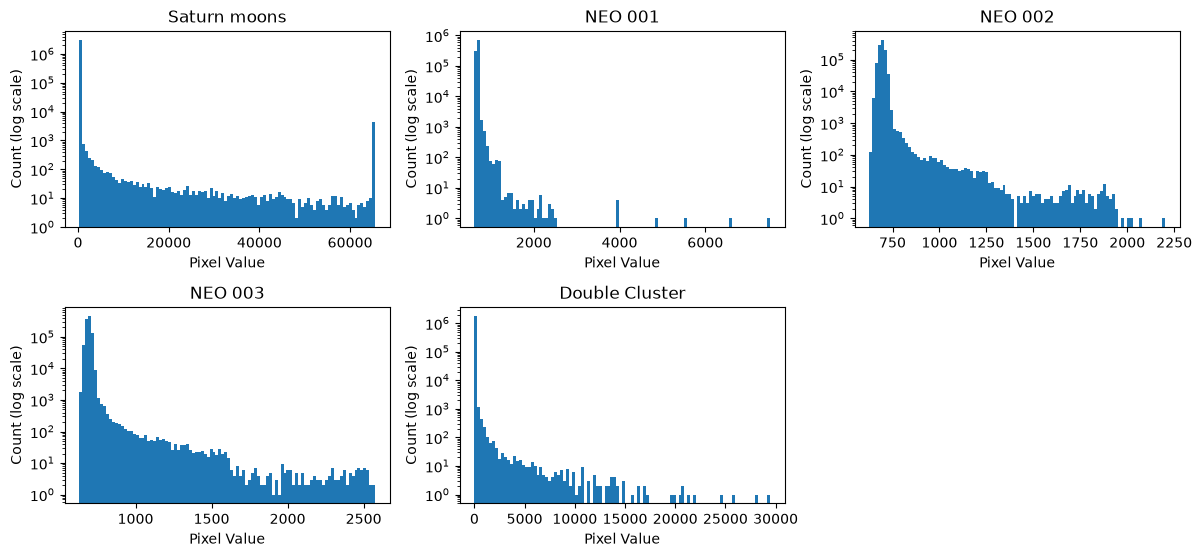

In [114]:
# histogram of pixel values for each image with log-y axis
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for i, image in enumerate(images):
    plt.subplot(3, 3, i + 1)
    plt.hist(image[0].data.flatten(), bins=100, log=True)
    plt.title(index_to_image_name[i])
    plt.xlabel("Pixel Value")
    plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.show()


### Discussion about the above graphs of count (on log scale) vs. pixel value

#### Saturn's Moons

Here we see that most pixels are close to the background value (likely around the median of 319 reported above), with a significant number of pixels at the max value around $2^{16}$. These features are likely due to a dark background sky that means most pixels receive few photons, and the presence of the very bright Saturn, which saturates many pixels at and around its position in the sky.

#### NEO Images

Here, we see the same broad picture: many pixels with low values and far fewer with higher values --- there's no ``peak" at a maximum brightness because seemingly there is no target in the frame bright enough to saturate pixels. Interestingly, the most common pixel value is not near zero, but rather a little above it --- evidence of a nonzero background level due to sky background and/or instrumental contributions. There are a few pixels with higher values in NEO 001, suggesting that there might be hot pixels or some error in that image.

#### Double Cluster

This is more similar to the Saturn photo, except it is significantly more right-skewed. There appear to be no saturated pixels, and we see many discrete sets of pixels at certain brightnesses above 10000 to 12000 (really, there are a small number of relatively bright stellar pixels). This is likely due to the large number of distinct point sources of light (stars) in this image, each of which has a different brightness and will cause varying levels of pixel intensities associated with stars of different brightnesses.


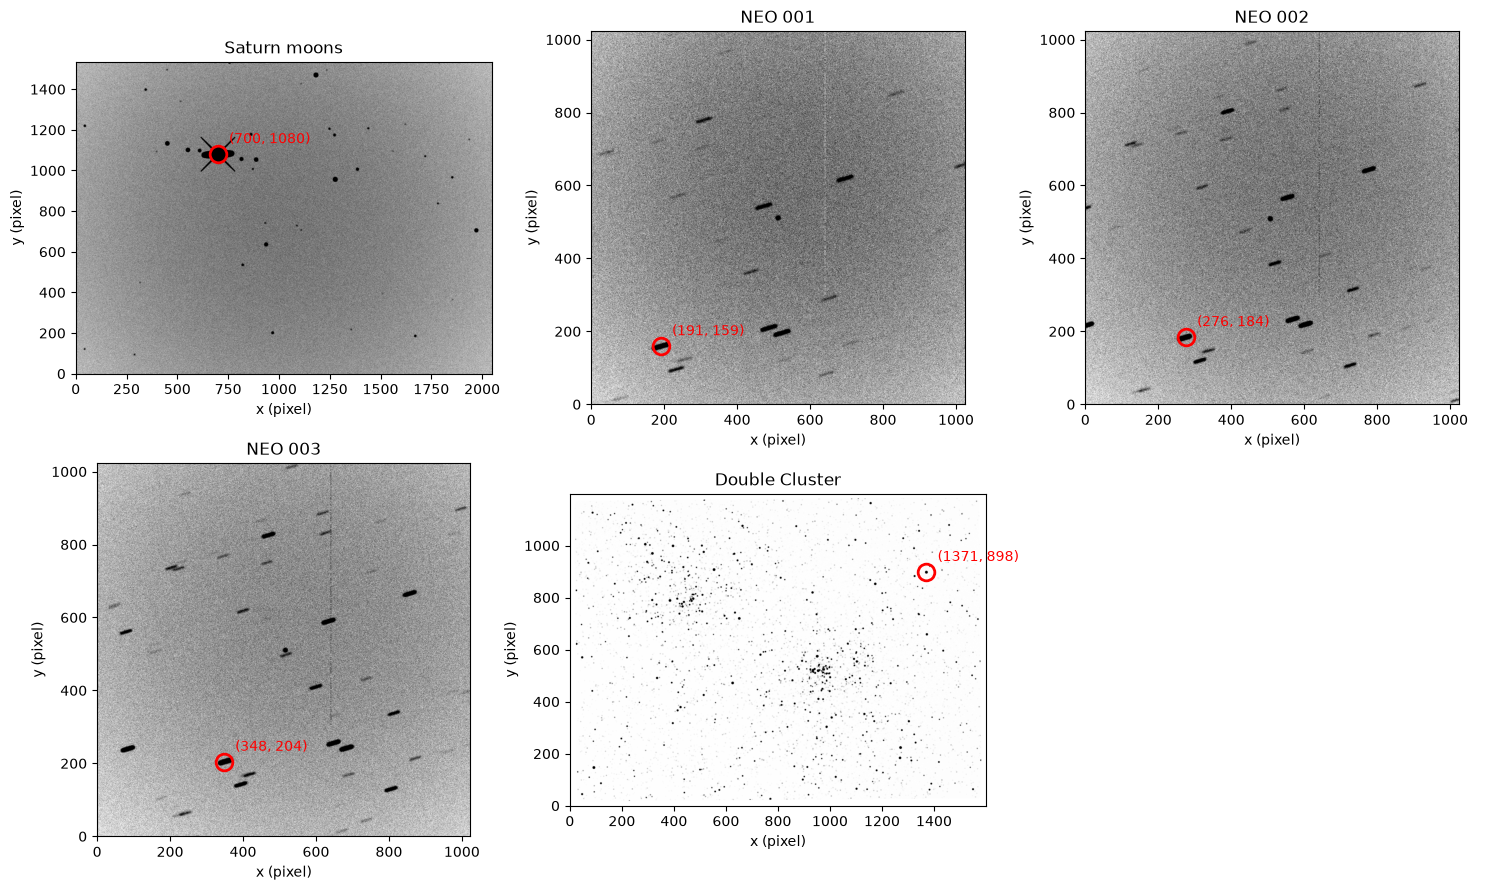

In [115]:
# Mark the brightest real source in each image, using pixel coordinates.
from scipy.ndimage import gaussian_filter, median_filter

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, (image, ax) in enumerate(zip(images, axes.flat)):
    data = image[0].data.astype(float)
    valid = np.isfinite(data)
    background = np.median(data[valid])
    filled = np.where(valid, data, background)

    # Mask invalid pixels and isolated positive spikes in the background.
    local_median = median_filter(filled, size=3)
    residual = filled - local_median
    noise = 1.4826 * np.median(np.abs(residual[valid] - np.median(residual[valid])))
    spikes = (residual > 8 * noise) & (local_median < background + 3 * noise)
    masked = np.ma.array(data, mask=~valid | spikes)

    # Smoothing ranks extended sources above single-pixel noise.
    clean = np.where(spikes, local_median, filled)
    score = gaussian_filter(median_filter(clean, size=3), sigma=2)
    score[~valid] = -np.inf
    if i == 0:  # Saturn has many equally bright saturated pixels.
        disk = valid & (data >= 0.99 * image[0].header['SATURATE'])
        yy, xx = np.where(disk)
        x, y = xx.mean(), yy.mean()
    else:
        y, x = np.unravel_index(np.argmax(score), score.shape)

    ax.imshow(masked, cmap='gray_r', origin='lower',
              vmin=background - 3 * noise, vmax=np.percentile(data[valid], 99.5))
    ax.plot(x, y, 'o', mfc='none', mec='red', ms=12, mew=2)
    ax.annotate(f'({x:.0f}, {y:.0f})', (x, y), xytext=(8, 8),
                textcoords='offset points', color='red')
    ax.set(title=index_to_image_name[i], xlabel='x (pixel)', ylabel='y (pixel)')

axes.flat[-1].axis('off')
fig.tight_layout()
plt.show()


## Part 2

All plots should use an inverted monochrome colormap. Include a color bar with an appropriate label including units. Include a scale bar of appropriate length. 

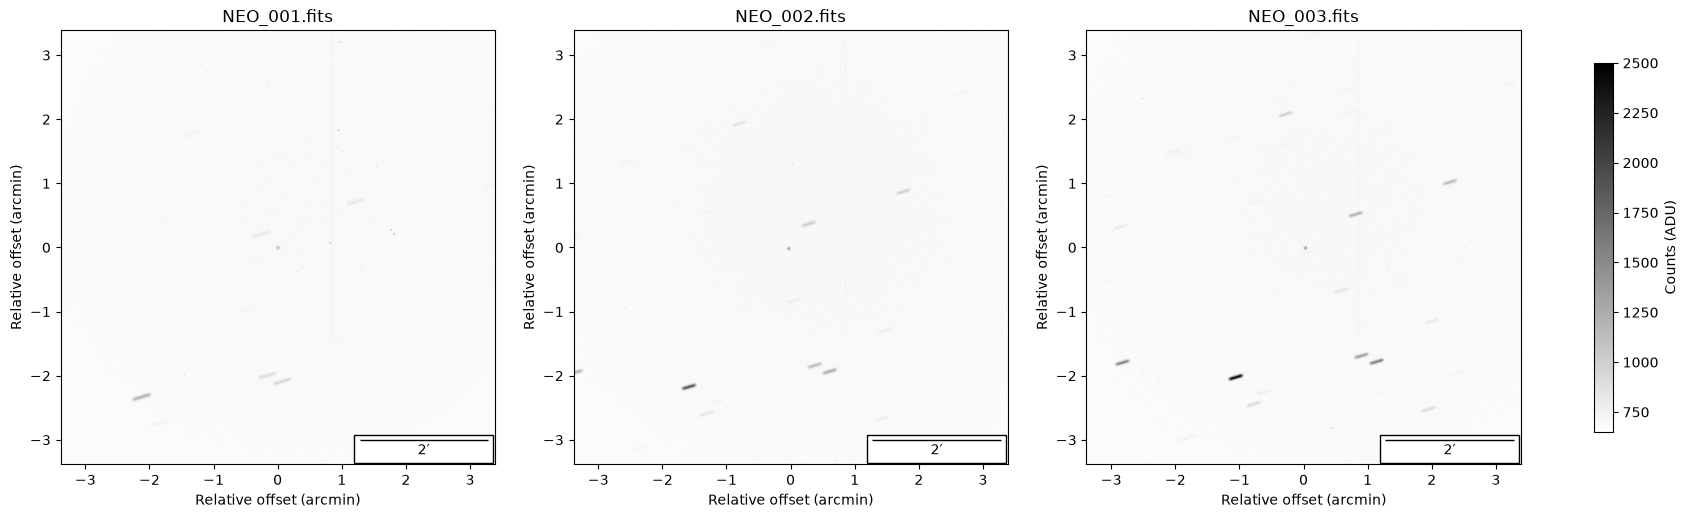

In [116]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

fig, axes = plt.subplots(1, 3, figsize=(17, 5), layout='constrained')
for i, (neo, ax) in enumerate(zip(neo_images, axes), start=1):
    data = neo[0].data
    ny, nx = data.shape
    arcmin_per_pixel = neo[0].header['PIXSCALE'] / 60
    extent = (-nx / 2 * arcmin_per_pixel, nx / 2 * arcmin_per_pixel,
              -ny / 2 * arcmin_per_pixel, ny / 2 * arcmin_per_pixel)

    image = ax.imshow(data, origin='lower', cmap='gray_r', extent=extent,
                      vmin=650, vmax=2500)
    ax.add_artist(AnchoredSizeBar(ax.transData, 2, '2′', 'lower right',
                                  pad=0.4, color='black', frameon=True))
    ax.set(title=f'NEO_00{i}.fits', xlabel='Relative offset (arcmin)',
           ylabel='Relative offset (arcmin)')

fig.colorbar(image, ax=axes, label='Counts (ADU)', shrink=0.85)
plt.show()


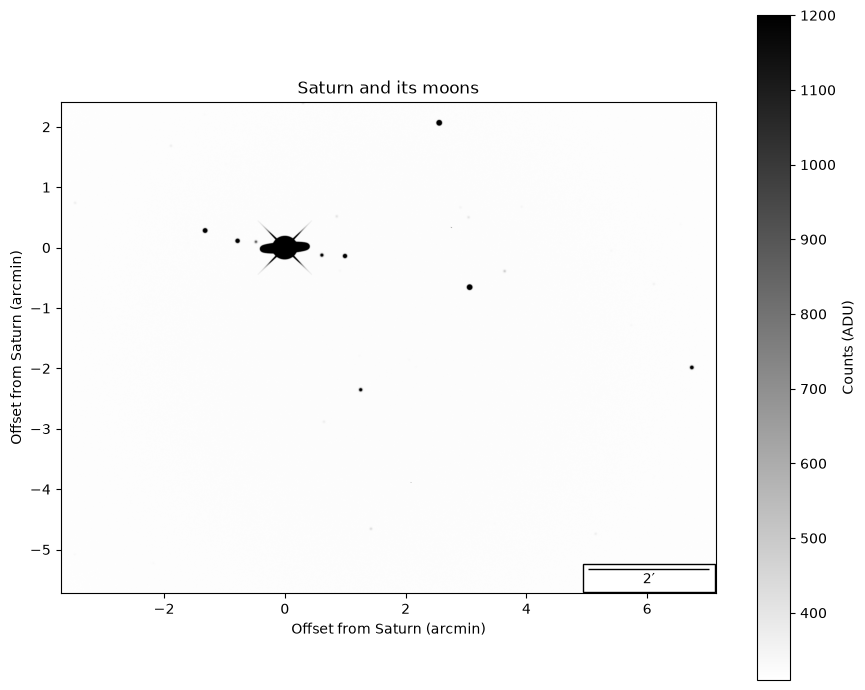

In [117]:
# Find Saturn from the centroid of its saturated disk, then use it as (0, 0).
saturn_data = saturn_moons[0].data
saturn_y, saturn_x = np.where(saturn_data >= 0.99 * saturn_moons[0].header['SATURATE'])
saturn_x, saturn_y = saturn_x.mean(), saturn_y.mean()
ny, nx = saturn_data.shape
arcmin_per_pixel = saturn_moons[0].header['PIXSCALE'] / 60
extent = ((-saturn_x - 0.5) * arcmin_per_pixel,
          (nx - saturn_x - 0.5) * arcmin_per_pixel,
          (-saturn_y - 0.5) * arcmin_per_pixel,
          (ny - saturn_y - 0.5) * arcmin_per_pixel)

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(saturn_data, origin='lower', cmap='gray_r', extent=extent,
                  vmin=310, vmax=1200)
fig.colorbar(image, ax=ax, label='Counts (ADU)')
ax.add_artist(AnchoredSizeBar(ax.transData, 2, '2′', 'lower right',
                              pad=0.4, color='black', frameon=True))
ax.set(title='Saturn and its moons', xlabel='Offset from Saturn (arcmin)',
       ylabel='Offset from Saturn (arcmin)')
fig.tight_layout()
plt.show()


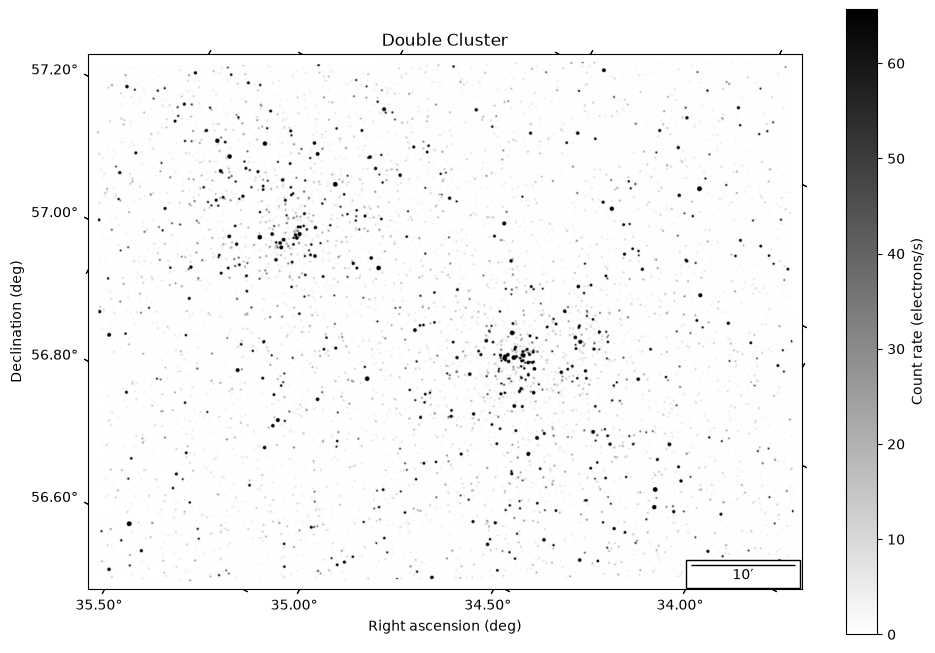

In [118]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from astropy.wcs import WCS
from astropy import units as u

# WCS solution obtained by plate-solving Double_Cluster.fits
# with Astrometry.net and downloading wcs.fits. Link is
# https://nova.astrometry.net/user_images/16391725
# Some "sanity check" data: (center 35.000 degrees, +57°08′00.176″; 2.585257 arcsec/pixel)
with fits.open("data/wcs.fits") as hdul:
    wcs = WCS(hdul[0].header)

cluster_data = double_cluster[0].data

fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={'projection': wcs})
image = ax.imshow(cluster_data, origin='lower', cmap='gray_r',
                  vmin=0, vmax=np.nanpercentile(cluster_data, 99.5))
fig.colorbar(image, ax=ax, label='Count rate (electrons/s)')
ax.add_artist(AnchoredSizeBar(ax.transData, 10 * 60 / double_cluster[0].header['PIXSCALE'],
                              '10′', 'lower right', pad=0.4,
                              color='black', frameon=True))
ax.coords[0].set_axislabel('Right ascension (deg)')
ax.coords[1].set_axislabel('Declination (deg)')
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')
ax.set_title('Double Cluster')
fig.tight_layout()
plt.show()
